In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Results folder:", RESULTS_DIR)

Results folder: ..\results


In [3]:
test_result_files = sorted(RESULTS_DIR.glob("*test_results.csv"))

print("Found test result files:")
for file in test_result_files:
    print(file.name)

Found test result files:
light_temporal_fusion_K3_attention_test_results.csv
proposed_change_aware_K5_uniform_noframedrop_test_results.csv
proposed_change_aware_K5_uniform_test_results.csv
single_frame_cnn_test_results.csv
temporal_pooling_K3_mean_test_results.csv
temporal_pooling_K5_mean_test_results.csv
temporal_pooling_K8_mean_test_results.csv
two_frame_change_cnn_test_results.csv


In [4]:
all_results = []

for file in test_result_files:
    df = pd.read_csv(file)

    for _, row in df.iterrows():
        row_dict = row.to_dict()
        row_dict["result_file"] = file.name
        all_results.append(row_dict)

comparison_df = pd.DataFrame(all_results)

comparison_df

,model,K,strategy,fusion_type,test_accuracy,test_precision,test_recall,test_f1,test_auc,result_file,frame_drop_prob,pooling_type,input_type
0,cnn_gru_light_temporal_fusion,3,uniform,attention,0.442623,0.431034,0.961538,0.595238,0.704396,light_temporal_fusion_K3_attention_test_result...,NaN,NaN,NaN
1,proposed_change_aware_attention,5,uniform,NaN,0.426230,0.426230,1.000000,0.597701,0.639560,proposed_change_aware_K5_uniform_noframedrop_t...,0.25,NaN,NaN
2,proposed_change_aware_attention,5,uniform,NaN,0.442623,0.431034,0.961538,0.595238,0.576923,proposed_change_aware_K5_uniform_test_results.csv,0.25,NaN,NaN
3,single_frame_cnn,1,recent,NaN,0.540984,0.476190,0.769231,0.588235,0.696703,single_frame_cnn_test_results.csv,NaN,NaN,NaN
4,temporal_pooling_cnn,3,uniform,NaN,0.524590,0.472727,1.000000,0.641975,0.730769,temporal_pooling_K3_mean_test_results.csv,NaN,mean,NaN
5,temporal_pooling_cnn,5,uniform,NaN,0.540984,0.480769,0.961538,0.641026,0.620879,temporal_pooling_K5_mean_test_results.csv,NaN,mean,NaN
6,temporal_pooling_cnn,8,uniform,NaN,0.590164,0.511628,0.846154,0.637681,0.615385,temporal_pooling_K8_mean_test_results.csv,NaN,mean,NaN
7,two_frame_change_cnn,2,early_late,NaN,0.590164,0.515152,0.653846,0.576271,0.703297,two_frame_change_cnn_test_results.csv,NaN,NaN,stacked_6_channel


In [5]:
metric_cols = [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_auc"
]

for col in metric_cols:
    if col in comparison_df.columns:
        comparison_df[col] = pd.to_numeric(comparison_df[col], errors="coerce")

comparison_df["experiment_name"] = comparison_df["result_file"].str.replace(
    "_test_results.csv",
    "",
    regex=False
)

# Put important columns first
first_cols = [
    "experiment_name",
    "model",
    "K",
    "strategy",
    "pooling_type",
    "fusion_type",
    "input_type",
    "frame_drop_prob",
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_auc",
    "result_file"
]

available_cols = [col for col in first_cols if col in comparison_df.columns]
remaining_cols = [col for col in comparison_df.columns if col not in available_cols]

comparison_df = comparison_df[available_cols + remaining_cols]

comparison_df.to_csv(RESULTS_DIR / "final_model_comparison.csv", index=False)

comparison_df

,experiment_name,model,K,strategy,pooling_type,fusion_type,input_type,frame_drop_prob,test_accuracy,test_precision,test_recall,test_f1,test_auc,result_file
0,light_temporal_fusion_K3_attention,cnn_gru_light_temporal_fusion,3,uniform,NaN,attention,NaN,NaN,0.442623,0.431034,0.961538,0.595238,0.704396,light_temporal_fusion_K3_attention_test_result...
1,proposed_change_aware_K5_uniform_noframedrop,proposed_change_aware_attention,5,uniform,NaN,NaN,NaN,0.25,0.426230,0.426230,1.000000,0.597701,0.639560,proposed_change_aware_K5_uniform_noframedrop_t...
2,proposed_change_aware_K5_uniform,proposed_change_aware_attention,5,uniform,NaN,NaN,NaN,0.25,0.442623,0.431034,0.961538,0.595238,0.576923,proposed_change_aware_K5_uniform_test_results.csv
3,single_frame_cnn,single_frame_cnn,1,recent,NaN,NaN,NaN,NaN,0.540984,0.476190,0.769231,0.588235,0.696703,single_frame_cnn_test_results.csv
4,temporal_pooling_K3_mean,temporal_pooling_cnn,3,uniform,mean,NaN,NaN,NaN,0.524590,0.472727,1.000000,0.641975,0.730769,temporal_pooling_K3_mean_test_results.csv
5,temporal_pooling_K5_mean,temporal_pooling_cnn,5,uniform,mean,NaN,NaN,NaN,0.540984,0.480769,0.961538,0.641026,0.620879,temporal_pooling_K5_mean_test_results.csv
6,temporal_pooling_K8_mean,temporal_pooling_cnn,8,uniform,mean,NaN,NaN,NaN,0.590164,0.511628,0.846154,0.637681,0.615385,temporal_pooling_K8_mean_test_results.csv
7,two_frame_change_cnn,two_frame_change_cnn,2,early_late,NaN,NaN,stacked_6_channel,NaN,0.590164,0.515152,0.653846,0.576271,0.703297,two_frame_change_cnn_test_results.csv


In [6]:
comparison_sorted_df = comparison_df.sort_values(
    by="test_f1",
    ascending=False
).reset_index(drop=True)

comparison_sorted_df["rank"] = comparison_sorted_df.index + 1

comparison_sorted_df.to_csv(
    RESULTS_DIR / "final_model_comparison_sorted.csv",
    index=False
)

comparison_sorted_df

,experiment_name,model,K,strategy,pooling_type,fusion_type,input_type,frame_drop_prob,test_accuracy,test_precision,test_recall,test_f1,test_auc,result_file,rank
0,temporal_pooling_K3_mean,temporal_pooling_cnn,3,uniform,mean,NaN,NaN,NaN,0.524590,0.472727,1.000000,0.641975,0.730769,temporal_pooling_K3_mean_test_results.csv,1
1,temporal_pooling_K5_mean,temporal_pooling_cnn,5,uniform,mean,NaN,NaN,NaN,0.540984,0.480769,0.961538,0.641026,0.620879,temporal_pooling_K5_mean_test_results.csv,2
2,temporal_pooling_K8_mean,temporal_pooling_cnn,8,uniform,mean,NaN,NaN,NaN,0.590164,0.511628,0.846154,0.637681,0.615385,temporal_pooling_K8_mean_test_results.csv,3
3,proposed_change_aware_K5_uniform_noframedrop,proposed_change_aware_attention,5,uniform,NaN,NaN,NaN,0.25,0.426230,0.426230,1.000000,0.597701,0.639560,proposed_change_aware_K5_uniform_noframedrop_t...,4
4,light_temporal_fusion_K3_attention,cnn_gru_light_temporal_fusion,3,uniform,NaN,attention,NaN,NaN,0.442623,0.431034,0.961538,0.595238,0.704396,light_temporal_fusion_K3_attention_test_result...,5
5,proposed_change_aware_K5_uniform,proposed_change_aware_attention,5,uniform,NaN,NaN,NaN,0.25,0.442623,0.431034,0.961538,0.595238,0.576923,proposed_change_aware_K5_uniform_test_results.csv,6
6,single_frame_cnn,single_frame_cnn,1,recent,NaN,NaN,NaN,NaN,0.540984,0.476190,0.769231,0.588235,0.696703,single_frame_cnn_test_results.csv,7
7,two_frame_change_cnn,two_frame_change_cnn,2,early_late,NaN,NaN,stacked_6_channel,NaN,0.590164,0.515152,0.653846,0.576271,0.703297,two_frame_change_cnn_test_results.csv,8


In [7]:
best_model_row = comparison_sorted_df.iloc[0]

print("Best model based on F1-score:")
print(best_model_row[["experiment_name", "test_accuracy", "test_precision", "test_recall", "test_f1", "test_auc"]])

Best model based on F1-score:
experiment_name    temporal_pooling_K3_mean
test_accuracy                       0.52459
test_precision                     0.472727
test_recall                             1.0
test_f1                            0.641975
test_auc                           0.730769
Name: 0, dtype: object


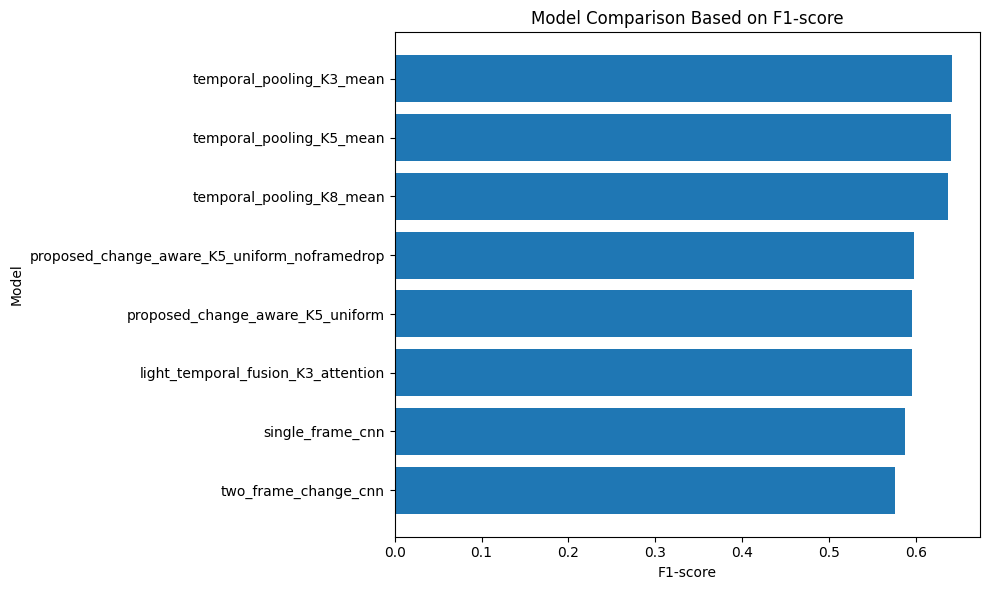

In [8]:
plot_df = comparison_sorted_df.sort_values("test_f1", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["experiment_name"], plot_df["test_f1"])
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.title("Model Comparison Based on F1-score")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "f1_score_comparison.png", dpi=300)
plt.show()

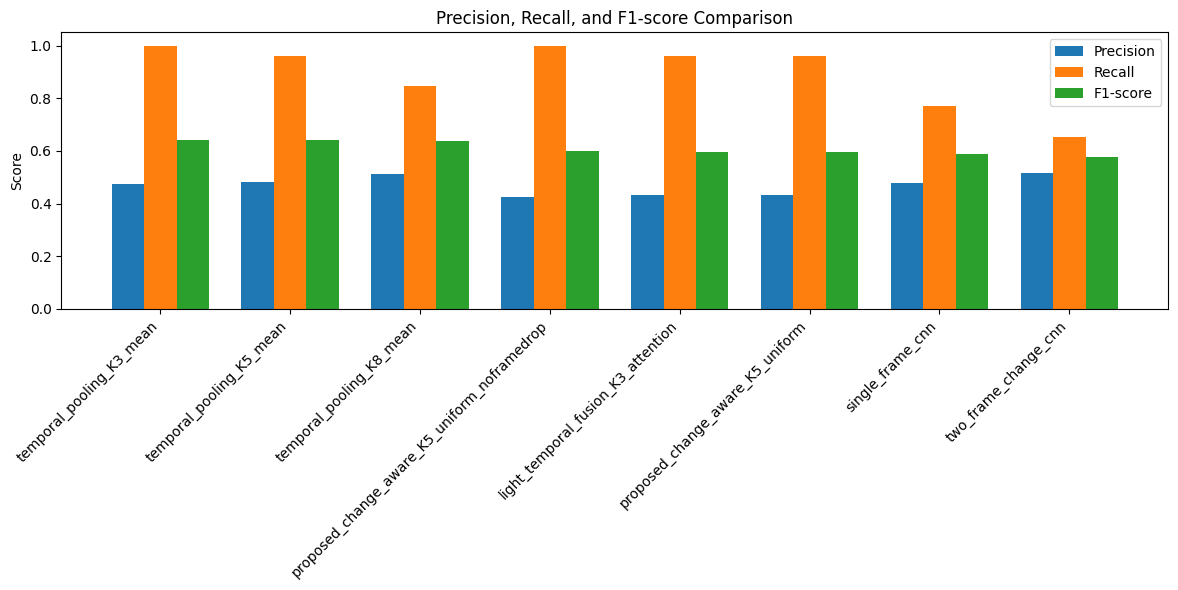

In [9]:
plot_df = comparison_sorted_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, plot_df["test_precision"], width, label="Precision")
plt.bar(x, plot_df["test_recall"], width, label="Recall")
plt.bar(x + width, plot_df["test_f1"], width, label="F1-score")

plt.xticks(x, plot_df["experiment_name"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "precision_recall_f1_comparison.png", dpi=300)
plt.show()

In [10]:
thesis_table = comparison_sorted_df[
    [
        "rank",
        "experiment_name",
        "model",
        "K",
        "strategy",
        "test_accuracy",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_auc"
    ]
].copy()

thesis_table = thesis_table.round(4)

thesis_table.to_csv(
    RESULTS_DIR / "thesis_final_result_table.csv",
    index=False
)

thesis_table

,rank,experiment_name,model,K,strategy,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,1,temporal_pooling_K3_mean,temporal_pooling_cnn,3,uniform,0.5246,0.4727,1.0000,0.6420,0.7308
1,2,temporal_pooling_K5_mean,temporal_pooling_cnn,5,uniform,0.5410,0.4808,0.9615,0.6410,0.6209
2,3,temporal_pooling_K8_mean,temporal_pooling_cnn,8,uniform,0.5902,0.5116,0.8462,0.6377,0.6154
3,4,proposed_change_aware_K5_uniform_noframedrop,proposed_change_aware_attention,5,uniform,0.4262,0.4262,1.0000,0.5977,0.6396
4,5,light_temporal_fusion_K3_attention,cnn_gru_light_temporal_fusion,3,uniform,0.4426,0.4310,0.9615,0.5952,0.7044
5,6,proposed_change_aware_K5_uniform,proposed_change_aware_attention,5,uniform,0.4426,0.4310,0.9615,0.5952,0.5769
6,7,single_frame_cnn,single_frame_cnn,1,recent,0.5410,0.4762,0.7692,0.5882,0.6967
7,8,two_frame_change_cnn,two_frame_change_cnn,2,early_late,0.5902,0.5152,0.6538,0.5763,0.7033


In [11]:
def predict_proposed_model(model, dataloader, source_df, device, k):
    model.eval()

    prediction_rows = []
    row_index = 0

    with torch.no_grad():
        for frames, temporal_mask, labels in dataloader:
            frames = frames.to(device)
            temporal_mask = temporal_mask.to(device)
            labels = labels.to(device)

            outputs = model(frames, temporal_mask)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            batch_size = labels.size(0)

            for j in range(batch_size):
                source_row = source_df.iloc[row_index + j]

                pred_label = int(preds[j].cpu().item())
                true_label = int(labels[j].cpu().item())
                prob_looted = float(probs[j].cpu().item())

                result = {
                    "site_id": source_row["site_id"],
                    "class_name": source_row["class_name"],
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "prob_looted": prob_looted,
                    "correct": int(true_label == pred_label)
                }

                for i in range(1, k + 1):
                    result[f"frame_{i}_path"] = source_row[f"frame_{i}_path"]

                prediction_rows.append(result)

            row_index += batch_size

    return pd.DataFrame(prediction_rows)

In [15]:
import torch
import torch.nn as nn

class ProposedChangeAwareModel(nn.Module):
    def __init__(self, num_classes=2, feature_dim=128):
        super(ProposedChangeAwareModel, self).__init__()

        self.feature_dim = feature_dim
        self.change_feature_dim = feature_dim * 2

        self.cnn_encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, feature_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.temporal_attention = nn.Sequential(
            nn.Linear(self.change_feature_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(self.change_feature_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, temporal_mask=None):
        batch_size, k, c, h, w = x.shape

        x = x.reshape(batch_size * k, c, h, w)

        features = self.cnn_encoder(x)
        features = features.reshape(batch_size, k, self.feature_dim)

        reference_feature = features[:, 0:1, :]
        change_feature = torch.abs(features - reference_feature)

        change_aware_features = torch.cat([features, change_feature], dim=-1)

        scores = self.temporal_attention(change_aware_features)

        if temporal_mask is not None:
            temporal_mask = temporal_mask.unsqueeze(-1)
            scores = scores.masked_fill(temporal_mask == 0, -1e9)

        weights = torch.softmax(scores, dim=1)

        fused_feature = torch.sum(change_aware_features * weights, dim=1)

        output = self.classifier(fused_feature)

        return output

print("ProposedChangeAwareModel defined successfully ✅")

ProposedChangeAwareModel defined successfully ✅


In [16]:
print(ProposedChangeAwareModel)

<class '__main__.ProposedChangeAwareModel'>


In [18]:
K = 5
STRATEGY = "uniform"

RESULTS_DIR = Path("../results")

best_model_path = RESULTS_DIR / f"proposed_change_aware_K{K}_{STRATEGY}_best.pth"

print("Loading proposed model from:", best_model_path)

best_model = ProposedChangeAwareModel(
    num_classes=2,
    feature_dim=128
).to(device)

best_model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

best_model.eval()

print("Proposed model loaded successfully ✅")

Loading proposed model from: ..\results\proposed_change_aware_K5_uniform_best.pth


NameError: name 'device' is not defined